# Graded Response Model — NPI (Single Scale)

Fits a single-dimensional GRM to all 40 NPI items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.npi import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items")
print(f"Response cardinality: {response_cardinality}")
print(f"Items: {item_keys}")
df.head()

Dataset: 11243 people, 40 items
Response cardinality: 2
Items: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40']


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,1,1,0,1,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,1,0,1,0,0,0,1,1,1,0,1
1,1,1,1,0,1,1,0,1,0,0,1,1,1,0,1,1,0,0,1,0,1,1,0,1,1,1,1,0,1,1,1,0,1,1,0,1,1,1,1,0
2,0,1,1,0,1,0,1,0,1,1,1,0,0,0,0,0,1,1,0,0,1,1,1,1,0,1,0,0,1,0,1,1,0,0,1,0,0,1,0,1
3,0,0,1,1,1,0,1,0,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,1,0,1,1,0,0,1,0,0,1,0,1,1,0,0
4,0,1,0,0,0,1,0,1,0,1,1,1,1,1,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,1,0,1,1,0,1,1,1,-1,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 11243


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 1422
N: 11243, Batch size: 256, Steps per epoch: 44


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
%%capture
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
%%capture
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=40,
    n_jobs=1,
    seed=42,
)

In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 40 targets


In [10]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.zero_predictor_results:
            zr = model.zero_predictor_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue
        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)
        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0: opt_w /= opt_w.sum()
        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0
        names = [m[0] for m in models_info]
        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": names[np.argmax(default_w)], "w_def": f"{default_w.max():.3f}",
            "Top_optimal": names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-",
            "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item  N Eff_def Eff_opt Top_default w_def   Top_optimal w_opt
  Q1 79    75.4    79.0     reg:Q11 0.017 reg:intercept 0.013
  Q2 79    76.8    79.0      reg:Q7 0.016 reg:intercept 0.013
  Q3 79    77.3    79.0     reg:Q35 0.015 reg:intercept 0.013
  Q4 80    78.3    80.0     reg:Q26 0.015 reg:intercept 0.013
  Q5 79    75.3    79.0     reg:Q27 0.017 reg:intercept 0.013
  Q6 80    76.6    80.0     reg:Q13 0.016 reg:intercept 0.013
  Q7 80    77.0    80.0     reg:Q30 0.016 reg:intercept 0.013
  Q8 79    75.3    79.0     reg:Q33 0.017 reg:intercept 0.013
  Q9 80    76.3    80.0     reg:Q40 0.016 reg:intercept 0.013
 Q10 79    75.2    79.0     reg:Q33 0.017 reg:intercept 0.013
 Q11 80    76.1    80.0     reg:Q12 0.016 reg:intercept 0.013
 Q12 80    76.3    80.0     reg:Q33 0.016 reg:intercept 0.013
 Q13 80    76.9    80.0      reg:Q6 0.016 reg:intercept 0.013
 Q14 79    76.3    79.0     reg:Q40 0.016 reg:intercept 0.013
 Q15

## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [11]:
%%capture
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

## 4b. Build Mixed Imputation Model

Blend MICE and IRT baseline predictions using per-item WAIC-based weights.
The IRT model's per-item WAIC provides a bias-corrected estimate comparable
to the MICE model's LOO-ELPD.

In [12]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 40 items, 11243 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
Q1              1.000    -0.6393    -0.6794     0.000
Q2              1.000    -0.4806    -0.7298     0.000
Q3              0.689    -0.4329    -0.4905     0.000
Q4              1.000    -0.4221    -0.9542     0.000
Q5              1.000    -0.6422    -0.8711     0.000
Q6              1.000    -0.6124    -0.7212     0.000
Q7              1.000    -0.5650    -0.7334     0.000
Q8              1.000    -0.6446    -0.7465     0.000
Q9              1.000    -0.6409    -0.7489     0.000
Q10             1.000    -0.6515    -0.8924     0.000
Q11             0.653    -0.6647    -0.6724     0.000
Q12             1.000    -0.6327    -0.6683     0.000
Q13             1.000    -0.5766    -0.6504     0.000
Q14             0.559    -0.5441    -0.5575     0.000
Q15             1.000    -0.4966    -0.7026     0.000
Q16             1.000    -0.

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [13]:
%%capture
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        dtype=jnp.float64,
        imputation_model=mixed_imputation,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        lr_decay_factor=0.975,
        patience=10,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )
    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IndexError: list index out of range

In [14]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

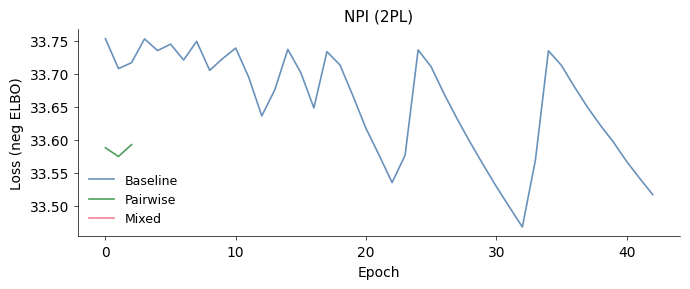

In [15]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='NPI (2PL)',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [17]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/40 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
  Q1     1.0000    0.0010              False
  Q2     1.0000    0.0010              False
  Q3     0.6891    0.0010              False
  Q4     1.0000    0.0010              False
  Q5     1.0000    0.0010              False
  Q6     1.0000    0.0010              False
  Q7     1.0000    0.0010              False
  Q8     1.0000    0.0010              False
  Q9     1.0000    0.0010              False
 Q10     1.0000    0.0010              False
 Q11     0.6533    0.0010              False
 Q12     1.0000    0.0010              False
 Q13     1.0000    0.0010              False
 Q14     0.5588    0.0010              False
 Q15     1.0000    0.0010              False
 Q16     1.0000    0.0010              False
 Q17     1.0000    0.0010              False
 Q18     1.0000    0.0010              False
 Q19     1.0000    0.0010              False
 Q20     1.0000    0.0010              False

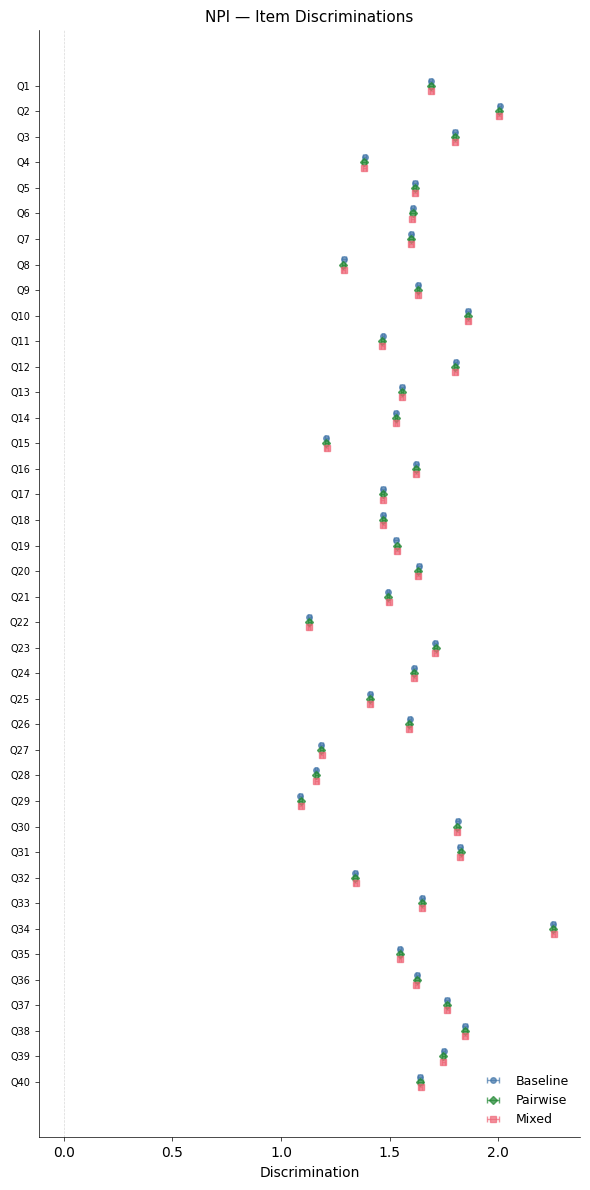

In [18]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                   title='NPI — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

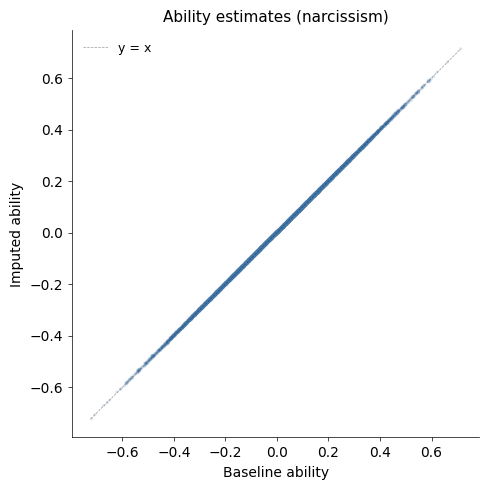

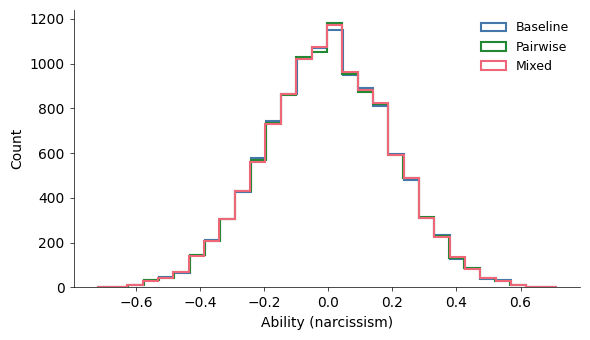

In [19]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='narcissism')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='narcissism',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

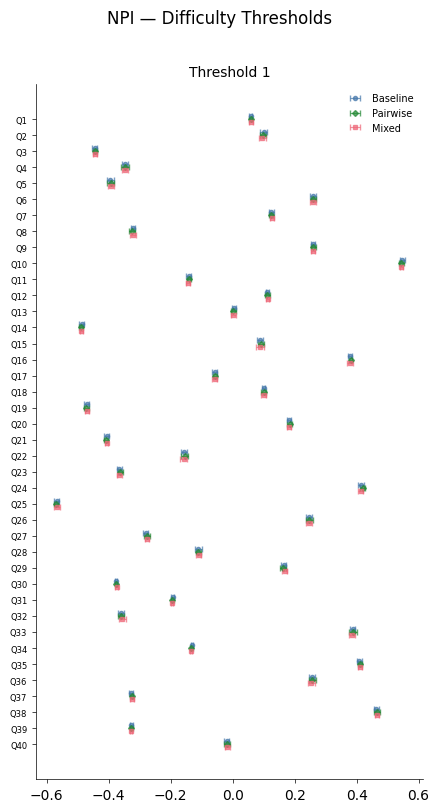

In [20]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                       title='NPI — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

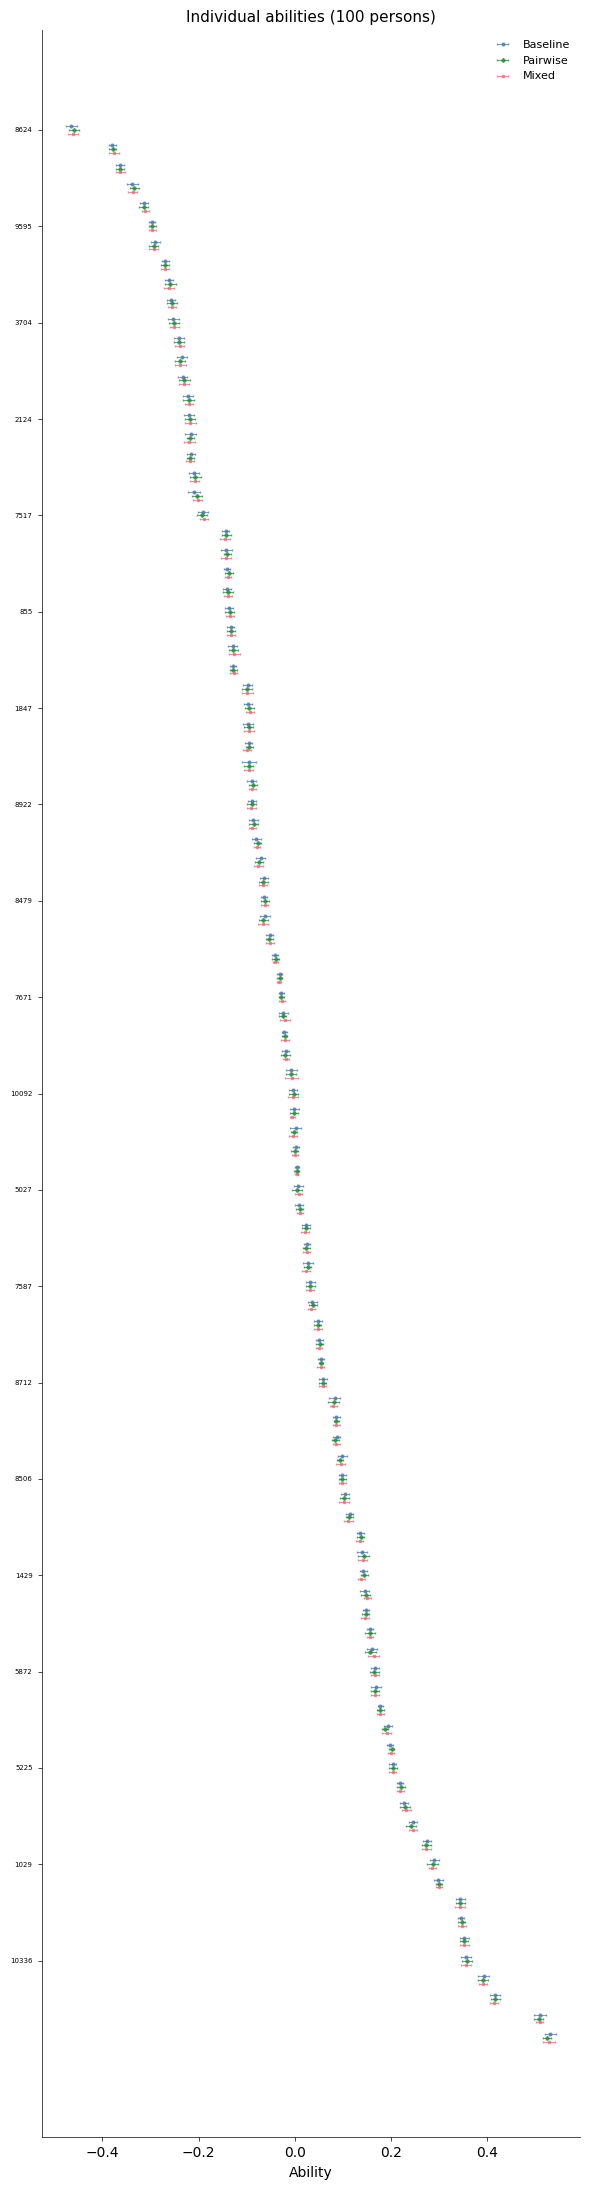

In [21]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

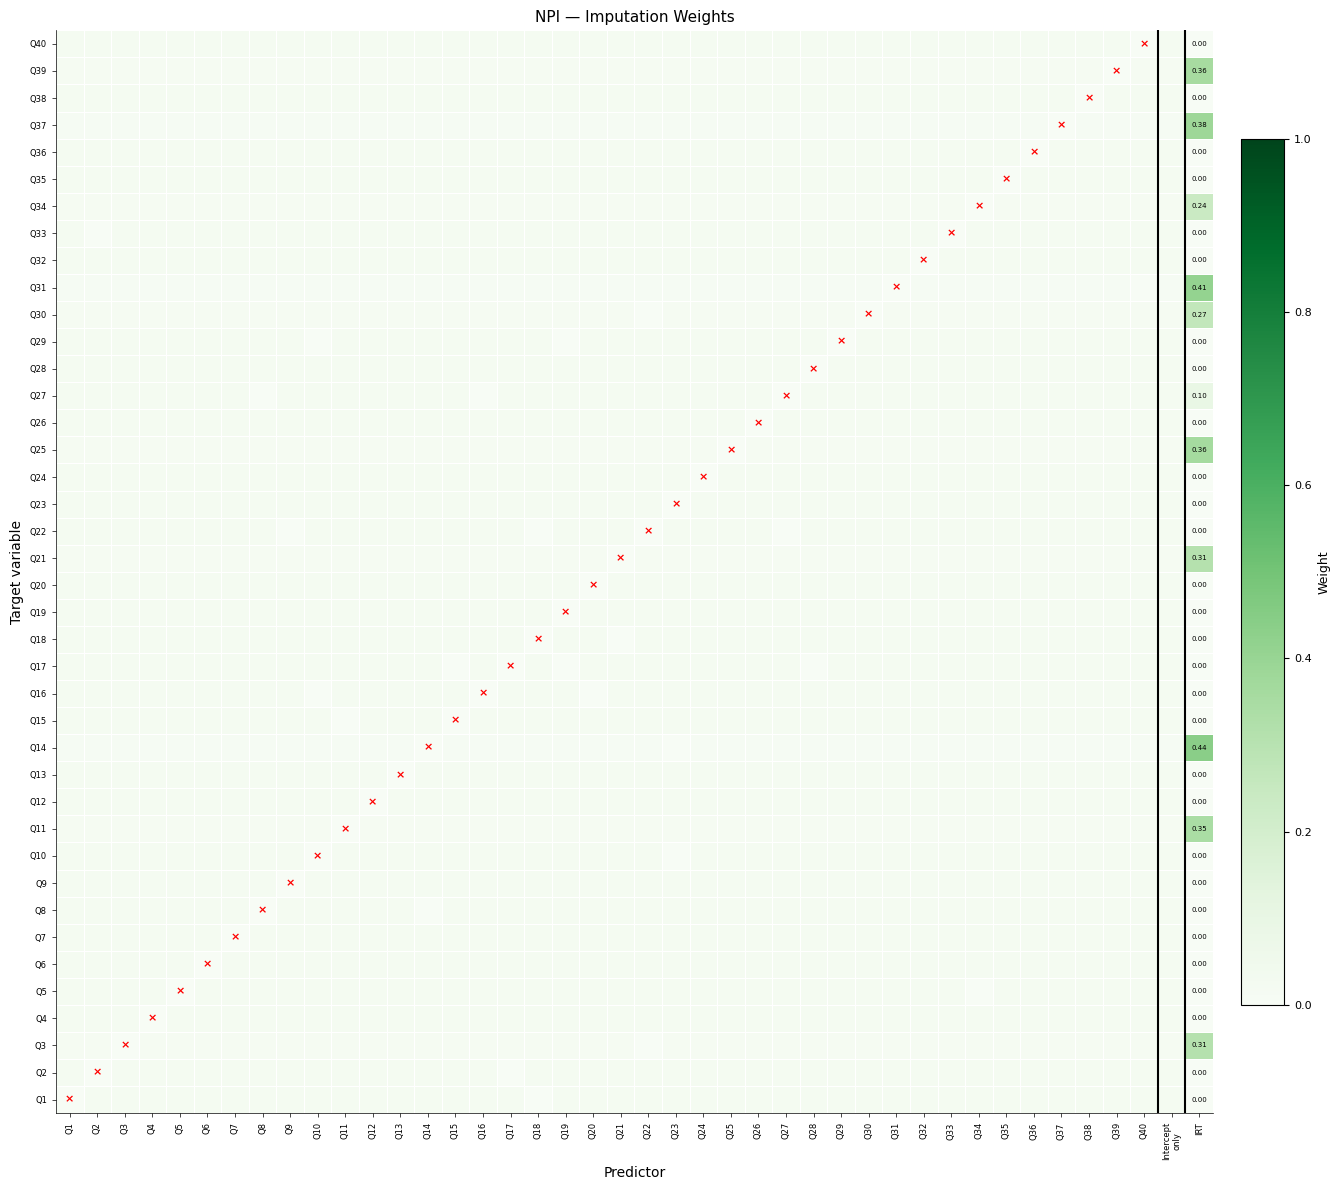

In [22]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='NPI — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

In [23]:
import pandas as pd

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                se += (np.sum(probs[:, n, i, :].mean(0) * np.arange(K)) - y_int) ** 2
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp']:
    rows.append({
        'Metric': metric,
        'Baseline': f"{m_b[metric][0]:.3f} ({m_b[metric][1]:.3f})",
        'Pairwise': f"{m_p[metric][0]:.3f} ({m_p[metric][1]:.3f})",
        'Mixed': f"{m_m[metric][0]:.3f} ({m_m[metric][1]:.3f})",
    })
print("NPI — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))

NPI — Predictive Performance Comparison

   Metric        Baseline        Pairwise           Mixed
     RMSE   0.518 (0.000)   0.518 (0.000)   0.518 (0.000)
   ELPD/n -29.250 (0.017) -29.247 (0.017) -29.237 (0.017)
ELPD/resp  -0.733 (0.000)  -0.733 (0.000)  -0.733 (0.000)


## Summary

This notebook fitted a single-scale Graded Response Model to all 40 NPI
items with 7 response categories. Three models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable.
2. **Pairwise GRM** -- uses only the pairwise ordinal stacking ensemble (w=1).
3. **Mixed GRM** -- blends the pairwise ensemble with the baseline IRT model's
   marginalized predictions via per-item stacking weights.